In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("customer_data.csv")
df.head()

,Customer_ID,Age,Gender,Income,Purchases,Total_Spend,Last_Purchase_Days_Ago,Membership_Years,Preferred_Category,Churn
0,CUST001,23,Male,25000,5,12000,12,1,Electronics,No
1,CUST002,35,Female,48000,12,45000,45,3,Fashion,No
2,CUST003,29,Male,32000,3,8000,90,2,Groceries,Yes
3,CUST004,42,Female,67000,20,98000,5,5,Electronics,No
4,CUST005,31,Male,54000,7,23000,60,3,Fashion,Yes


In [9]:
df_json=pd.read_json("customer_data.json")
df_json.head()

,Customer_ID,Age,Gender,Income,Purchases,Total_Spend,Last_Purchase_Days_Ago,Membership_Years,Preferred_Category,Churn
0,CUST001,23,Male,25000,5,12000,12,1,Electronics,No
1,CUST002,35,Female,48000,12,45000,45,3,Fashion,No
2,CUST003,29,Male,32000,3,8000,90,2,Groceries,Yes
3,CUST004,42,Female,67000,20,98000,5,5,Electronics,No
4,CUST005,31,Male,54000,7,23000,60,3,Fashion,Yes


In [10]:
import pandas as pd

# Step 1: Create a sample SQL file
sql_content = """
-- Get all customers with purchases above 300
SELECT Name, Age, Purchase_Amount
FROM customers
WHERE Purchase_Amount > 300;
"""

with open("customer_query.sql", "w") as f:
    f.write(sql_content)

# Step 2: Read SQL file into Python
with open("customer_query.sql", "r") as file:
    query = file.read()

print("SQL Query from file:\n", query)

# Step 3: Store SQL query inside a DataFrame for review
df_sql = pd.DataFrame({"SQL_Query": [query]})
print("\nStored in DataFrame:\n", df)

SQL Query from file:
 
-- Get all customers with purchases above 300
SELECT Name, Age, Purchase_Amount
FROM customers
WHERE Purchase_Amount > 300;


Stored in DataFrame:
    Customer_ID  Age  Gender  Income  Purchases  Total_Spend  \
0      CUST001   23    Male   25000          5        12000   
1      CUST002   35  Female   48000         12        45000   
2      CUST003   29    Male   32000          3         8000   
3      CUST004   42  Female   67000         20        98000   
4      CUST005   31    Male   54000          7        23000   
5      CUST006   27  Female   30000          4        10000   
6      CUST007   50    Male   85000         25       150000   
7      CUST008   38  Female   62000         15        72000   
8      CUST009   26    Male   28000          2         5000   
9      CUST010   45  Female   72000         18        89000   
10     CUST011   33    Male   40000          6        21000   
11     CUST012   28  Female   35000          5        15000   
12     CUS

In [11]:
import requests

url = "https://jsonplaceholder.typicode.com/users"
response = requests.get(url)

data = response.json()
df_api = pd.DataFrame(data)

print(df_api.head())

   id              name   username                      email  \
0   1     Leanne Graham       Bret          Sincere@april.biz   
1   2      Ervin Howell  Antonette          Shanna@melissa.tv   
2   3  Clementine Bauch   Samantha         Nathan@yesenia.net   
3   4  Patricia Lebsack   Karianne  Julianne.OConner@kory.org   
4   5  Chelsey Dietrich     Kamren   Lucio_Hettinger@annie.ca   

                                             address                  phone  \
0  {'street': 'Kulas Light', 'suite': 'Apt. 556',...  1-770-736-8031 x56442   
1  {'street': 'Victor Plains', 'suite': 'Suite 87...    010-692-6593 x09125   
2  {'street': 'Douglas Extension', 'suite': 'Suit...         1-463-123-4447   
3  {'street': 'Hoeger Mall', 'suite': 'Apt. 692',...      493-170-9623 x156   
4  {'street': 'Skiles Walks', 'suite': 'Suite 351...          (254)954-1289   

         website                                            company  
0  hildegard.org  {'name': 'Romaguera-Crona', 'catchPhrase': 'Mu

In [21]:
df.info()
df.describe()

#missing values 
print("missing values:",df.isnull().sum())

#duplicate values 
print("duplicate values:",df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Customer_ID             30 non-null     object
 1   Age                     30 non-null     int64 
 2   Gender                  30 non-null     object
 3   Income                  30 non-null     int64 
 4   Purchases               30 non-null     int64 
 5   Total_Spend             30 non-null     int64 
 6   Last_Purchase_Days_Ago  30 non-null     int64 
 7   Membership_Years        30 non-null     int64 
 8   Preferred_Category      30 non-null     object
 9   Churn                   30 non-null     object
dtypes: int64(6), object(4)
memory usage: 2.5+ KB
missing values: Customer_ID               0
Age                       0
Gender                    0
Income                    0
Purchases                 0
Total_Spend               0
Last_Purchase_Days_Ago    0
Membership_

In [12]:
# ================= MERGING ALL DATASETS =================

# Step 1: Standardize column names
df.columns = df.columns.str.strip().str.lower()
df_json.columns = df_json.columns.str.strip().str.lower()
df_sql.columns = df_sql.columns.str.strip().str.lower()
df_api.columns = df_api.columns.str.strip().str.lower()

# Step 2: Align columns
common_cols = df.columns

df_json = df_json.reindex(columns=common_cols)
df_sql = df_sql.reindex(columns=common_cols)
df_api = df_api.reindex(columns=common_cols)

# Step 3: Merge datasets
df_merged = pd.concat([df, df_json, df_sql, df_api], ignore_index=True)

# Step 4: Remove duplicates
df_merged.drop_duplicates(inplace=True)

# Step 5: Final check
print("Final Shape:", df_merged.shape)
print(df_merged.head())
print(df_merged.info())

Final Shape: (31, 10)
  customer_id   age  gender   income  purchases  total_spend  \
0     CUST001  23.0    Male  25000.0        5.0      12000.0   
1     CUST002  35.0  Female  48000.0       12.0      45000.0   
2     CUST003  29.0    Male  32000.0        3.0       8000.0   
3     CUST004  42.0  Female  67000.0       20.0      98000.0   
4     CUST005  31.0    Male  54000.0        7.0      23000.0   

   last_purchase_days_ago  membership_years preferred_category churn  
0                    12.0               1.0        Electronics    No  
1                    45.0               3.0            Fashion    No  
2                    90.0               2.0          Groceries   Yes  
3                     5.0               5.0        Electronics    No  
4                    60.0               3.0            Fashion   Yes  
<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 0 to 40
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------     

In [ ]:
#handle missing values
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

#fix datatypes
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])


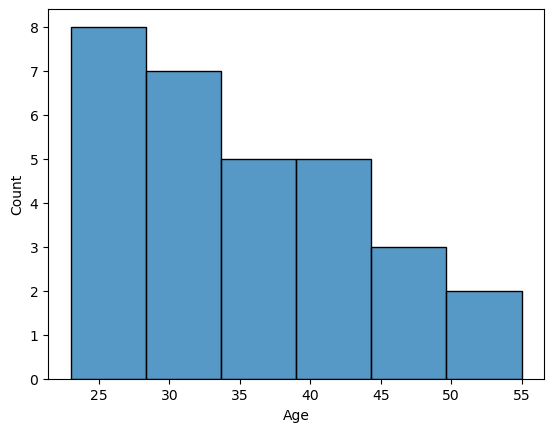

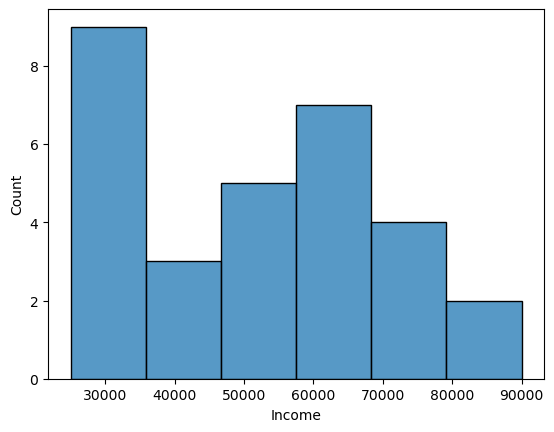

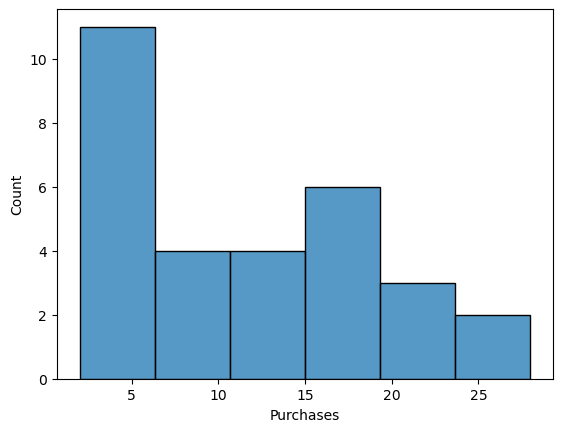

In [27]:


sns.histplot(df['Age'])
plt.show()

sns.histplot(df['Income'])
plt.show()

sns.histplot(df['Purchases'])
plt.show()

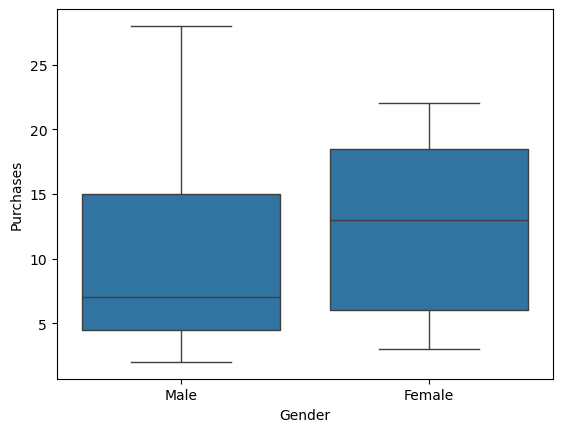

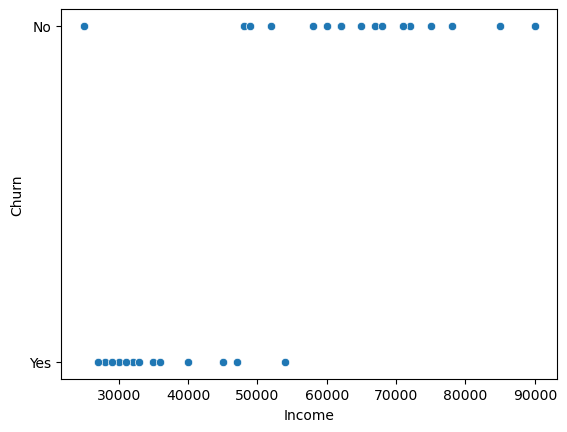

In [28]:
sns.boxplot(x='Gender', y='Purchases', data=df)
plt.show()

sns.scatterplot(x='Income', y='Churn', data=df)
plt.show()

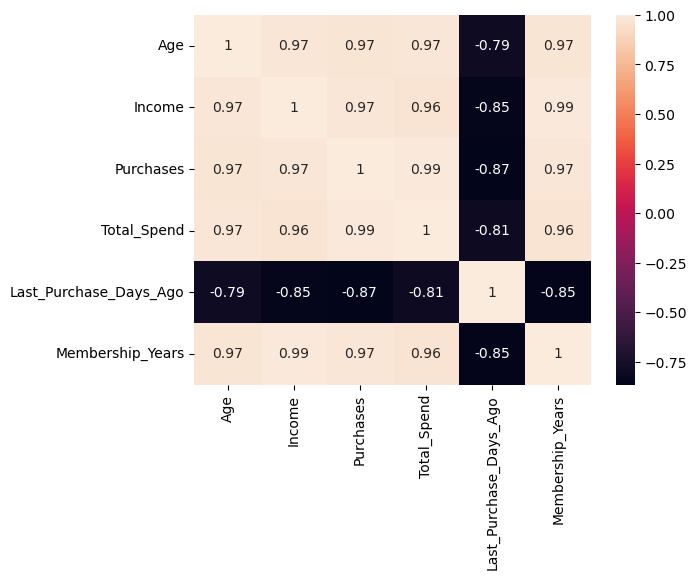

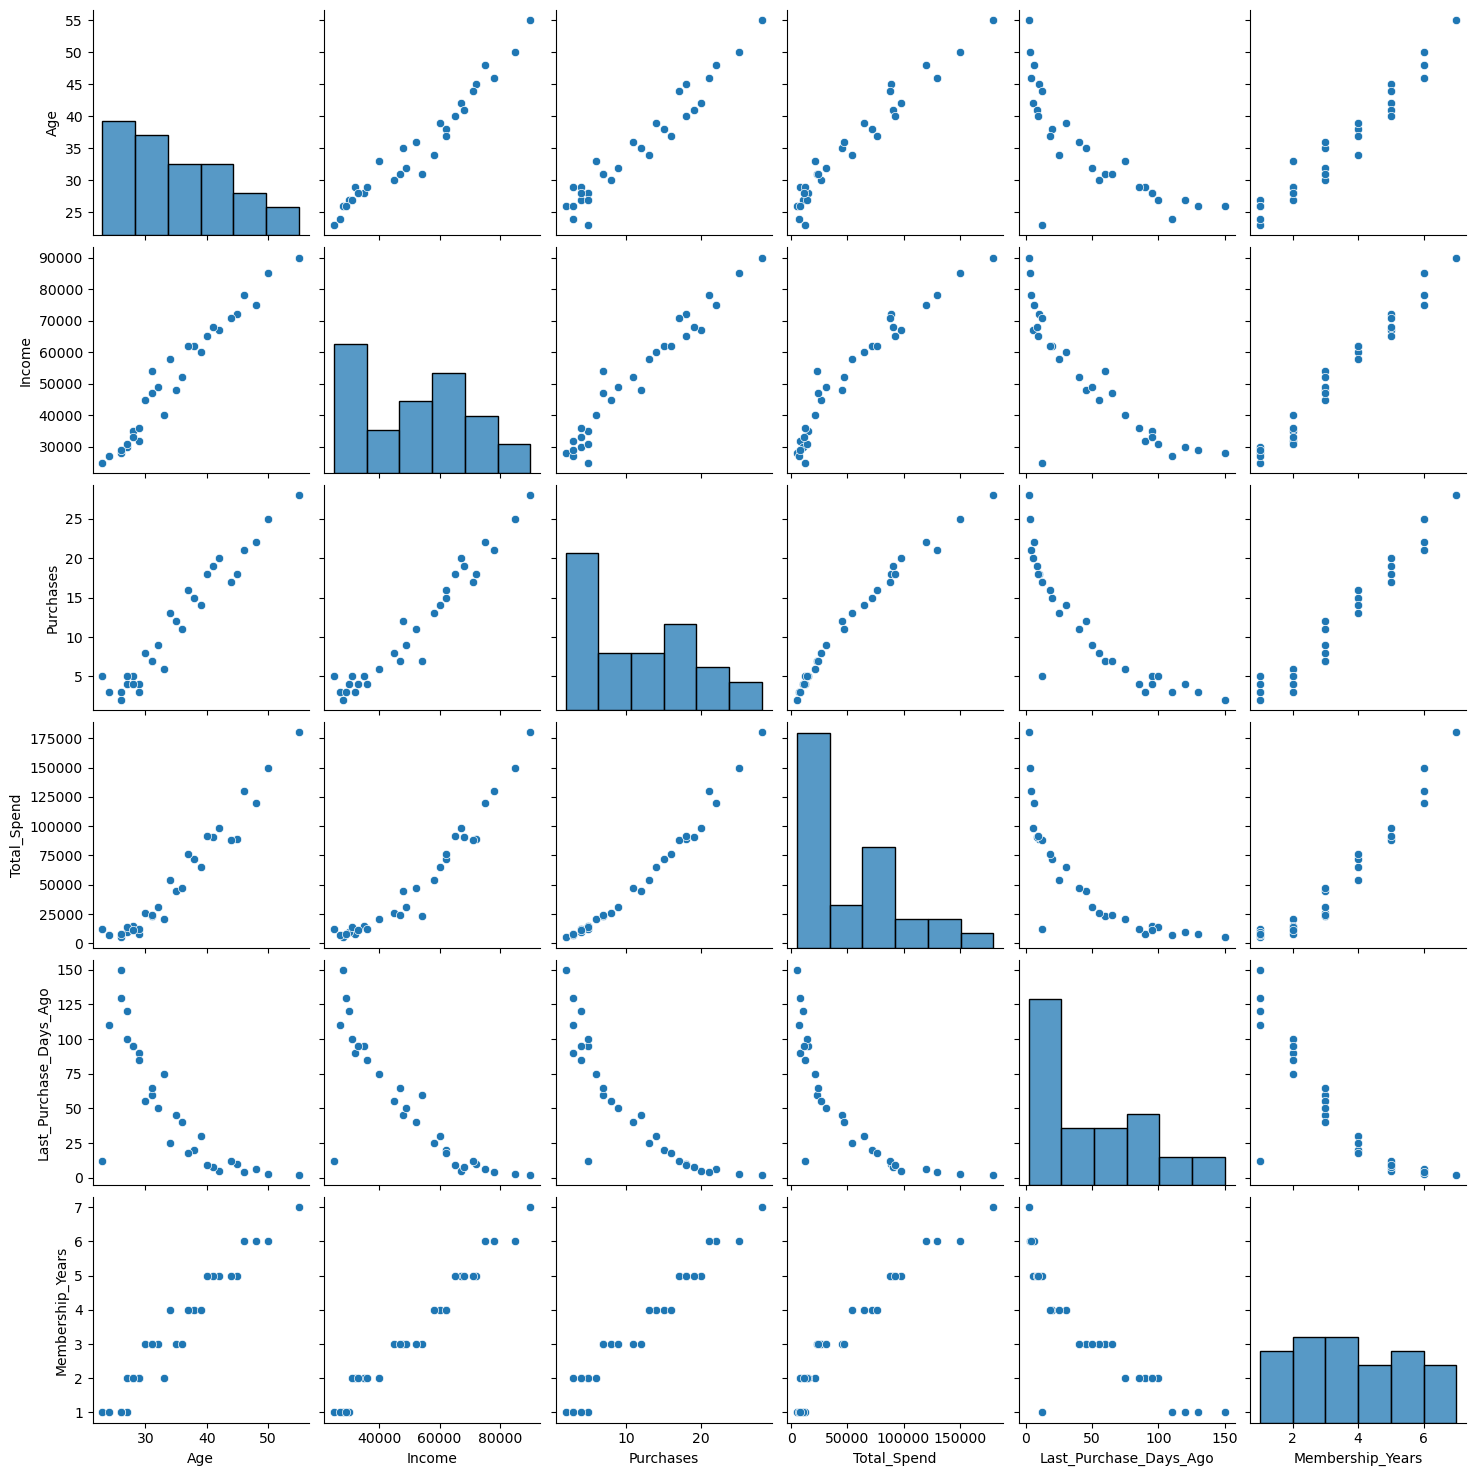

In [30]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.show()

sns.pairplot(df)
plt.show()

In [2]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, explorative=True)

profile.to_file("report.html")

C:\Users\yakshrajsinh\AppData\Local\Temp\ipykernel_1236\3726149161.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install data-profiling via `pip install data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 756.79it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]